# Cheng's consistency: a size effect, not reach

This notebook is a small, runnable demo of the experiment **"Cheng's consistency: size effect, not reach."**

**The question.** Cheng et al. (2023, *ASR*) found that *ideationally consistent* concepts, whose co-usage
neighbourhood stays stable from one year to the next, grow faster. Does that consistency predict a concept's later
**reach** (how many other fields it spreads to), or is it mostly a **size** effect?

**What the experiment does** (orchestrated by `method.py`, with the maths in `lib/*.py`):

| Step | What it does | In this demo? |
|---|---|---|
| S0 | frozen spec + seal before any model | no (bookkeeping only) |
| S1 | build Cheng measures (CONS, EMB, SOC) from cached OpenAlex rows | **measures are precomputed** and shipped in `mini_demo_data.json`. The `cons()` code is shown |
| S2 | construct-identity check | no |
| S3 | **Test A**: Cheng replication panel (PPML A1 / A2 / A3, NB twin, bootstrap A2/A1 ratio) | **yes** |
| S4 | **Test B**: static early trait vs reach and depth (partial Spearman, concept bootstrap) | **yes** |
| S5 | Test C: within-concept panel (needs Exp11's yearly panel) | no |
| S6 | **Test D**: Palla size × consistency interaction | **yes** |
| S7 | **Test E**: HOME vs ALL papers coupling | **yes** |
| S8 | verdict, figures, write-up | a mini verdict plus plots at the end |

**Full-run headline numbers** (12,499 concepts, 105,839 concept-years; *selection data, not confirmation*):
- The NB twin reproduces Cheng (b = 0.428, **+53.5%/SD** vs Cheng's +53%). PPML gives +83%/SD.
- Adding log V(t) leaves only **+1.3%/SD**. The A2/A1 ratio is 0.021 [0.009, 0.035], so the effect is **SIZE-DOMINATED**.
- Early consistency correlates with later volume (raw Spearman **+0.256**). Its partial Spearman with rarefied cross-field **reach** (O2r_m50) is **−0.069** [−0.093, −0.047], a **REVERSAL**. The depth outcomes are null.

The demo runs the **same code**, with the original bootstrap draw counts, on a stratified subset of
**100 concepts** (about 1,900 concept-year rows). Expect wide intervals: the point is to show the pipeline, not to
reproduce the full-run precision. The full-run numbers ship inside the data file and appear next to the demo numbers at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pyfixest, loguru: NOT pre-installed on Colab, always install
_pip('pyfixest==0.60.0', 'loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib: pre-installed on Colab, install locally only (Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

## Imports
This cell combines the import blocks of `method.py` and the `lib/` modules it drives (`panel_cheng.py`,
`static_cheng.py`, `cheng.py`, `rq1stats.py`). `matplotlib` is added for the final plots.

In [2]:
from __future__ import annotations

import argparse
import os
import sys

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):   # one BLAS thread per process: the
    os.environ.setdefault(_v, "1")                                         # steps parallelise across processes
import time
from pathlib import Path

import math
import multiprocessing as mp
import warnings
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

import matplotlib.pyplot as plt   # notebook addition: result plots

## Data loading
The loader tries the GitHub copy of `mini_demo_data.json` first and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-5/experiment-14/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(data["metadata"]["description"])
print("concepts:", len(examples), "| panel rows:", sum(len(e["panel"]) for e in examples))

100 EXP5 frame concepts (stratified by 8 field groups, seed 20260929) from the Cheng ideational-consistency experiment. static = early-trait row (B5 baseline, outcomes, CONS/EMB/SOC early traits); panel = Cheng concept-year measures for t0+1..min(t0+10,2021), HOME and ALL builds; V = grounded paper volume per year (t0-3..t0+11).
concepts: 100 | panel rows: 1936


## Configuration
All tunable parameters are here. The bootstrap draw counts match the original run: 500 for the Test A ratio,
2000 for Test B primary, 500 for secondary traits, 1000 for Palla and 2000 for coupling. Because the demo has only
100 concepts, the full notebook still runs in a few minutes. The only scale reduction is the concept count: 100
here versus 12,499 in the full run, which read cached OpenAlex rows not bundled with this demo. To iterate
faster, lower the `N_BOOT_*` values (10 draws is enough to exercise every code path).
`WORKERS = 1` because `ProcessPoolExecutor(spawn)` cannot pickle functions defined inside a notebook.

In [5]:
N_CONCEPTS = 100        # concepts taken from mini_demo_data.json (max 100 bundled; full run: 12,499 EXP5 concepts)
N_BOOT_PANEL = 500      # test A cluster-bootstrap draws for the A2/A1 ratio      (original: 500)
N_BOOT_STATIC = 2000    # test B primary-trait psp bootstrap draws                (original: 2000)
N_BOOT_SECONDARY = 500  # test B secondary traits / volume_all draws              (original: 500)
N_BOOT_GROUP = 1000     # test B per-group draws (groups need >= 40 concepts)     (original: 1000)
N_BOOT_PALLA = 1000     # test D Palla interaction draws                          (original: 1000)
N_BOOT_COUPLING = 2000  # test E HOME-vs-ALL coupling draws                       (original: 2000)
WITH_NB = True          # fit the statsmodels NB2 twin of A1 (HOME build)
WORKERS = 1             # serial in the notebook (original: one worker per CPU)

## Shared constants and helpers (`lib/common.py`)
These constants are copied verbatim. Key definitions:
- **B5**: the five early-life baseline covariates (log volume, growth, off-home share, field entropy, reach).
- **REACH** outcomes: `O2r_m50` (rarefied venue-field richness at t0+6..t0+8) and `O2r_resid`.
- **DEPTH** outcomes: `O1c`, `O1b`, `O3`.
- **HOME** build: only papers in the concept's home field(s). **ALL** build: every grounded paper.

In [6]:
SEED = 20260929
MIN_PAPERS = 3                      # CONS / EMB defined iff >= 3 papers ...
MIN_TOPICS = 2                      # ... and >= 2 non-self topics in BOTH years (CONS) / in year t (EMB)

# frame group -> the five pooled groups of EXP10 (MATHDEC reported only)
GROUP5 = {"CS": "CS+Eng", "Eng": "CS+Eng", "BGM": "BGM+Med", "Med": "BGM+Med", "PHYS": "PHYS",
          "LIFEENV": "LIFEENV", "SOC": "SOC", "MATHDEC": "MATHDEC"}
GROUPS5 = ["CS+Eng", "BGM+Med", "PHYS", "LIFEENV", "SOC"]
BODIES_EXP5 = ["DEV", "OLD_HELDOUT", "COHORT_2010_14"]
BODY_COHORT = "COHORT_2015_17"
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
DEPTH = ["O1c", "O1b", "O3"]
REACH = ["O2r_m50", "O2r_resid"]
SELECTION_LABEL = "selection data, not confirmation"


def body_of_split(split: str) -> str:
    if split == "DEV":
        return "DEV"
    if split == "COHORT":
        return "COHORT_2010_14"
    return "OLD_HELDOUT"


def n_workers() -> int:
    return WORKERS          # notebook: fixed by the config cell (original read the cgroup CPU quota)


def setup_logger(name: str):
    from loguru import logger
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    # original also added a rotating file sink under logs/; omitted in the notebook
    return logger


logger = setup_logger("method")

## The measure: ideational consistency (`lib/cheng.py`, step S1)
For concept *c* and year *t*, `v_t[k]` counts the year-*t* papers of *c* tagged with topic *k*, excluding the
concept's own "self" topics. **CONS(t) = cosine(v_{t−1}, v_t)**. It is defined only when both years have ≥ 3
papers and ≥ 2 non-self topics. `CONS_r` is Cheng's verbatim variant, which restricts `v_t` to the support of `v_{t−1}`.

The full build ran this function over the concept's grounded OpenAlex papers (cached rows, not bundled here). The
precomputed values are in the `panel` records of the data file. The toy call below only shows what the function returns.

In [7]:
def cosine(u: np.ndarray, v: np.ndarray) -> float:
    nu, nv = float(np.sqrt(u @ u)), float(np.sqrt(v @ v))
    if nu == 0 or nv == 0:
        return 0.0
    return float(u @ v / (nu * nv))


def cons(v_prev: np.ndarray, v_cur: np.ndarray, n_prev: int, n_cur: int) -> tuple[float, float]:
    # (CONS, CONS_r). NaN unless both years have >= MIN_PAPERS papers and >= MIN_TOPICS non-self topics.
    if n_prev < MIN_PAPERS or n_cur < MIN_PAPERS:
        return float("nan"), float("nan")
    if (v_prev > 0).sum() < MIN_TOPICS or (v_cur > 0).sum() < MIN_TOPICS:
        return float("nan"), float("nan")
    c = cosine(v_prev, v_cur)
    supp = v_prev > 0
    vr = np.where(supp, v_cur, 0.0)
    cr = cosine(v_prev, vr)
    return c, cr


# toy illustration (notebook addition): neighbour-topic counts in two consecutive years
v_prev = np.array([4., 2., 0., 1., 0.])
v_cur = np.array([3., 2., 1., 0., 2.])
print("CONS, CONS_r =", cons(v_prev, v_cur, n_prev=5, n_cur=6))

CONS, CONS_r = (0.8229511997978236, 0.9683640522700839)


## Rebuild the input tables from the bundled data
The original steps read `frame_concepts.csv`, `data/cheng_features.parquet`, `data/V_exp5.parquet` and
`data/static_analysis_table.parquet` from disk. This cell rebuilds the same four tables in memory from
`mini_demo_data.json`, limited to the first `N_CONCEPTS` concepts. This is the only data-path change.

In [8]:
_ex = examples[:N_CONCEPTS]
FRAME = pd.DataFrame([{"ci": e["static"]["ci"], "t0": e["static"]["t0"], "group": e["static"]["group"],
                       "split": e["static"]["split"]} for e in _ex])
FEATURES = pd.DataFrame([{"ci": e["static"]["ci"], **r, "body_src": "EXP5"} for e in _ex for r in e["panel"]])
V_EXP5 = pd.DataFrame([{"ci": e["static"]["ci"], "year": int(y), "V": v} for e in _ex for y, v in e["V"].items()])
STATIC = pd.DataFrame([e["static"] for e in _ex])
for _c in FEATURES.columns.drop(["build", "body_src"]):
    FEATURES[_c] = pd.to_numeric(FEATURES[_c])            # JSON null -> NaN
STATIC = STATIC.apply(lambda s: pd.to_numeric(s) if s.name not in ("group", "split", "name", "body", "group5") else s)
print(FRAME.shape, FEATURES.shape, V_EXP5.shape, STATIC.shape)
FEATURES.head()

(100, 4) (1936, 12) (1468, 3) (100, 34)


,ci,year,build,n_papers,n_topics,CONS,CONS_r,EMB,EMB_cos,n_authors,SOC,body_src
0,60,2004,ALL,66,51,0.695007,0.775778,0.840897,0.171766,273,0.005226,EXP5
1,60,2005,ALL,72,58,0.746867,0.789964,0.802582,0.180605,280,0.007990,EXP5
2,60,2006,ALL,72,64,0.831745,0.904202,0.884450,0.182857,351,0.004070,EXP5
3,60,2007,ALL,74,75,0.753947,0.810688,0.892967,0.190783,377,0.004472,EXP5
4,60,2008,ALL,82,65,0.807531,0.845136,0.788014,0.167566,423,0.003719,EXP5


---
# Test A: Cheng replication panel (`lib/panel_cheng.py`, step S3)

**Panel:** concept-years t0+1 ≤ t ≤ min(t0+10, 2021) with finite CONS. The outcome is next-year volume V(t+1).
- **A1**: PPML `V(t+1) ~ zCONS + zEMB + zSOC | age + year`, Cheng's specification with SEs clustered by concept.
- **A2**: A1 plus `log1p V(t)`, the size control.
- **A3**: A2 with concept and year fixed effects.
- **A1‑NB**: statsmodels NB2 twin of A1, closest to Cheng's own estimator.
- **Ratio** b_A2 / b_A1 on zCONS, from a concept-cluster bootstrap. A small ratio means that consistency's
  "growth" effect is mostly current size.

`panel_A` is the original function with its three file reads replaced by the in-memory tables.

In [9]:
XS_JOINT = ["zCONS", "zEMB", "zSOC"]


# ----------------------------------------------------------------------------- data
def panel_A(build: str) -> pd.DataFrame:
    fr = FRAME[["ci", "t0", "group", "split"]].copy()                  # was: pd.read_csv(EXP5 / "frame_concepts.csv")
    fr["body"] = fr.split.map(body_of_split)
    fr["group5"] = fr.group.map(GROUP5)
    f = FEATURES                                                        # was: pd.read_parquet(DATA / "cheng_features.parquet")
    f = f[(f.body_src == "EXP5") & (f.build == build)][["ci", "year", "CONS", "EMB", "SOC", "n_papers", "n_topics"]]
    V = V_EXP5[["ci", "year", "V"]]                                     # was: pd.read_parquet(DATA / "V_exp5.parquet")
    d = f.merge(fr, on="ci")
    d = d[(d.year >= d.t0 + 1) & (d.year <= np.minimum(d.t0 + 10, 2021))]
    d = d.merge(V, on=["ci", "year"], how="left").merge(
        V.assign(year=V.year - 1).rename(columns={"V": "V_next"}), on=["ci", "year"], how="left")
    d = d[np.isfinite(d.CONS)].copy()
    d["age"] = d.year - d.t0
    d["logV"] = np.log1p(d.V)
    return d.reset_index(drop=True)


def zcols(d: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    d = d.copy()
    for c in cols:
        v = d[c].to_numpy(float)
        d["z" + c] = (v - np.nanmean(v)) / np.nanstd(v)
    return d

### Numpy Poisson IRLS and the cluster bootstrap of the A2/A1 ratio
Refitting pyfixest in every draw is slow. The original therefore bootstraps with a plain numpy Poisson IRLS on an
explicit dummy design (age and year fixed effects). The same resampled concepts are used for A1 and A2, so their
ratio is paired. The IRLS point estimate is checked against pyfixest (`irls_vs_pyfixest_abs_diff_A1`).

In [10]:
def dummy_design(d: pd.DataFrame, xs: list[str], fe: list[str]) -> tuple[np.ndarray, list[str]]:
    cols = [np.ones(len(d))]
    names = ["_const"]
    for c in xs:
        cols.append(d[c].to_numpy(float))
        names.append(c)
    for f in fe:
        v = d[f].to_numpy()
        for u in np.unique(v)[1:]:
            cols.append((v == u).astype(float))
            names.append(f"{f}={u}")
    return np.column_stack(cols), names


def poisson_irls(X: np.ndarray, y: np.ndarray, iters: int = 100, tol: float = 1e-10) -> np.ndarray:
    mu = y.mean() + 0.1
    b = np.zeros(X.shape[1])
    b[0] = math.log(mu)
    eta = X @ b
    for _ in range(iters):
        mu = np.exp(np.clip(eta, -30, 30))
        z = eta + (y - mu) / mu
        XtW = X.T * mu
        H = XtW @ X
        try:
            bn = np.linalg.solve(H, XtW @ z)
        except np.linalg.LinAlgError:
            bn = np.linalg.lstsq(H, XtW @ z, rcond=None)[0]
        if np.max(np.abs(bn - b)) < tol:
            b = bn
            break
        b = bn
        eta = X @ b
    return b


def _boot_ratio_worker(args) -> list[tuple[float, float]]:
    X1, X2, y, cl_idx, seeds = args
    out = []
    for s in seeds:
        rng = np.random.default_rng(s)
        pick = rng.integers(0, len(cl_idx), len(cl_idx))
        rows = np.concatenate([cl_idx[p] for p in pick])
        b1 = poisson_irls(X1[rows], y[rows])[1]
        b2 = poisson_irls(X2[rows], y[rows])[1]
        out.append((b1, b2))
    return out


def cluster_index(ci: np.ndarray) -> list[np.ndarray]:
    order = np.argsort(ci, kind="stable")
    u, start = np.unique(ci[order], return_index=True)
    return np.split(order, start[1:])


def boot_ratio(d: pd.DataFrame, xs: list[str], n_boot: int, seed: int, workers: int) -> dict:
    # Cluster bootstrap of b_A1 and b_A2 on the first regressor (zCONS), same draws.
    X1, _ = dummy_design(d, xs, ["age", "year"])
    X2, _ = dummy_design(d, xs + ["logV"], ["age", "year"])
    y = d.V_next.to_numpy(float)
    cl = cluster_index(d.ci.to_numpy())
    b1p, b2p = poisson_irls(X1, y)[1], poisson_irls(X2, y)[1]
    seeds = [seed + k for k in range(n_boot)]
    parts = [seeds[i::workers] for i in range(workers)]
    res = []
    if workers > 1:
        with ProcessPoolExecutor(max_workers=workers, mp_context=mp.get_context("spawn")) as ex:
            for r in ex.map(_boot_ratio_worker, [(X1, X2, y, cl, p) for p in parts]):
                res.extend(r)
    else:
        res = _boot_ratio_worker((X1, X2, y, cl, seeds))
    B = np.array(res)
    ratio = B[:, 1] / B[:, 0]
    pr = b2p / b1p
    return {"b_A1_irls": b1p, "b_A2_irls": b2p, "ratio": pr,
            "ratio_ci": np.percentile(ratio, [2.5, 97.5]).tolist(), "ratio_boot_median": float(np.median(ratio)),
            "b_A1_ci_boot": np.percentile(B[:, 0], [2.5, 97.5]).tolist(),
            "b_A2_ci_boot": np.percentile(B[:, 1], [2.5, 97.5]).tolist(),
            "p_one_ratio_lt_0.5": float((np.sum(ratio >= 0.5) + 1) / (len(ratio) + 1)),
            "p_one_A1_gt_0": float((np.sum(B[:, 0] <= 0) + 1) / (len(B) + 1)),
            "n_boot": int(len(B)), "resampling_unit": "concept (cluster bootstrap)", "boot_b": B}

### Model wrappers: pyfixest PPML/OLS with CRV1 SEs, and the statsmodels NB2 twin
`pct_per_sd = exp(b) − 1` is the % change in next-year volume per 1 SD of the regressor.

In [11]:
def fepois(d: pd.DataFrame, y: str, xs: list[str], fe: str) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = pf.fepois(f"{y} ~ {' + '.join(xs)} | {fe}", data=d, vcov={"CRV1": "ci"})
    return summarize(fit, xs, d)


def feols(d: pd.DataFrame, y: str, xs: list[str], fe: str) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = pf.feols(f"{y} ~ {' + '.join(xs)} | {fe}", data=d, vcov={"CRV1": "ci"})
    return summarize(fit, xs, d)


def summarize(fit, xs: list[str], d: pd.DataFrame) -> dict:
    co, se, pv = fit.coef(), fit.se(), fit.pvalue()
    ci = fit.confint()
    out = {"n_rows": int(fit._N), "n_concepts": int(d.ci.nunique()), "coef": {}}
    for x in xs:
        if x not in co.index:
            continue
        b = float(co[x])
        out["coef"][x] = {"b": b, "se": float(se[x]), "ci": [float(ci.loc[x].iloc[0]), float(ci.loc[x].iloc[1])],
                          "p": float(pv[x]), "pct_per_sd": math.exp(b) - 1,
                          "pct_ci": [math.exp(float(ci.loc[x].iloc[0])) - 1, math.exp(float(ci.loc[x].iloc[1])) - 1]}
    return out


def nb_fit(d: pd.DataFrame, xs: list[str]) -> dict:
    import statsmodels.api as sm
    X, names = dummy_design(d, xs, ["age", "year"])
    y = d.V_next.to_numpy(float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = sm.NegativeBinomial(y, X, loglike_method="nb2")
        try:
            r = m.fit(disp=0, maxiter=300, method="bfgs", cov_type="cluster", cov_kwds={"groups": d.ci.to_numpy()})
            how = "bfgs"
        except np.linalg.LinAlgError:
            # retry: Newton from the Poisson IRLS solution and alpha = 0.5
            sp0 = np.r_[poisson_irls(X, y), 0.5]
            r = m.fit(start_params=sp0, disp=0, maxiter=100, method="newton", cov_type="cluster",
                      cov_kwds={"groups": d.ci.to_numpy()})
            how = "newton (retry after singular bfgs)"
    out = {"n_rows": int(len(y)), "alpha": float(r.params[-1]), "converged": bool(r.mle_retvals.get("converged", True)),
           "optimizer": how, "coef": {}}
    for i, nm in enumerate(names):
        if nm in xs:
            b, s = float(r.params[i]), float(r.bse[i])
            out["coef"][nm] = {"b": b, "se": s, "ci": [b - 1.96 * s, b + 1.96 * s], "pct_per_sd": math.exp(b) - 1,
                               "p": float(2 * stats.norm.sf(abs(b / s)))}
    return out

### DerSimonian–Laird random-effects pooling (`lib/rq1stats.py`)
This pools per-group estimates. The full run fits each of the 5 field groups separately (only groups with ≥ 30
concepts in Test A and ≥ 40 in Test B), then pools them. With 100 concepts no group reaches that size, so the
pooled result has `k = 0`.

In [12]:
def dersimonian_laird(b, se) -> dict:
    # EXP6 lib/stats_core.dersimonian_laird (verbatim logic).
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}

### Run Test A for both builds (HOME, ALL)
This is `run_A` as in the original, with two notebook changes. The bootstrap draw count comes from the config
instead of the `--quick` flag. Results stay in memory instead of going to `results/cheng_panel_models.json` and
`data/boot_ratio_*.npy`.

In [13]:
def fit_A_set(d: pd.DataFrame, xs: list[str], with_A3: bool = True, with_nb: bool = False) -> dict:
    out = {"A1": fepois(d, "V_next", xs, "age + year"),
           "A2": fepois(d, "V_next", xs + ["logV"], "age + year")}
    if with_A3:
        out["A3"] = fepois(d, "V_next", xs + ["logV"], "ci + year")
    if with_nb:
        try:
            out["A1_NB"] = nb_fit(d, xs)
        except (ValueError, np.linalg.LinAlgError) as e:
            out["A1_NB"] = {"error": repr(e)[:300]}
    b1 = out["A1"]["coef"].get("zCONS", {}).get("b", np.nan)
    b2 = out["A2"]["coef"].get("zCONS", {}).get("b", np.nan)
    out["ratio_point"] = b2 / b1 if b1 else float("nan")
    return out


def run_A(logger, workers: int = 0) -> dict:
    W = workers or n_workers()
    nb = N_BOOT_PANEL                                       # was: 60 if quick else N_BOOT_PANEL
    res = {"label": SELECTION_LABEL, "resampling_unit": "concept", "n_boot": nb,
           "spec": "PPML (pyfixest fepois); CRV1 by concept; X standardised over the rows of each model",
           "EMB_note": "EMB is an ANALOGUE of Cheng's word2vec embeddedness (backbone PMI), not the same measure",
           "builds": {}}
    for build in ["HOME", "ALL"]:
        t = time.time()
        d0 = panel_A(build)
        d0 = d0[np.isfinite(d0.V_next)]
        dj = zcols(d0.dropna(subset=["EMB", "SOC"]), ["CONS", "EMB", "SOC"])
        dc = zcols(d0, ["CONS"])
        B = {"n_rows_CONS": int(len(dc)), "n_rows_joint": int(len(dj)), "n_concepts_joint": int(dj.ci.nunique()),
             "share_rows_dropped_for_EMB_SOC": 1 - len(dj) / max(len(dc), 1),
             "CONS_mean": float(d0.CONS.mean()), "CONS_sd": float(d0.CONS.std())}
        B["joint"] = fit_A_set(dj, XS_JOINT, with_A3=True, with_nb=(WITH_NB and build == "HOME"))
        B["cons_only"] = fit_A_set(dc, ["zCONS"], with_A3=True, with_nb=(WITH_NB and build == "HOME"))
        logger.info(f"A {build}: joint A1 {B['joint']['A1']['coef']['zCONS']} A2 {B['joint']['A2']['coef']['zCONS']}")
        # bootstrap ratio (headline = HOME joint), plus CONS-only
        br = boot_ratio(dj, XS_JOINT, nb, SEED, W)
        pf1 = B["joint"]["A1"]["coef"]["zCONS"]["b"]
        br["irls_vs_pyfixest_abs_diff_A1"] = abs(br["b_A1_irls"] - pf1)
        br.pop("boot_b")                                    # was: np.save(DATA / f"boot_ratio_{build}_joint.npy", ...)
        B["joint"]["ratio_boot"] = br
        brc = boot_ratio(dc, ["zCONS"], nb, SEED + 7, W)
        brc.pop("boot_b")
        B["cons_only"]["ratio_boot"] = brc
        logger.info(f"A {build}: ratio {br['ratio']:.3f} CI {br['ratio_ci']} (irls-pf diff "
                    f"{br['irls_vs_pyfixest_abs_diff_A1']:.2e}); cons-only {brc['ratio']:.3f} {brc['ratio_ci']}")
        # per body / per group (joint, A1 and A2, CRV1) + DL across groups
        B["by_body"] = {}
        for bd in sorted(d0.body.unique()):
            g = zcols(d0[d0.body == bd].dropna(subset=["EMB", "SOC"]), ["CONS", "EMB", "SOC"])
            B["by_body"][bd] = fit_A_set(g, XS_JOINT, with_A3=False)
        B["by_group"] = {}
        for gname in GROUPS5 + ["MATHDEC"]:
            g = zcols(d0[d0.group5 == gname].dropna(subset=["EMB", "SOC"]), ["CONS", "EMB", "SOC"])
            if g.ci.nunique() < 30:
                continue
            B["by_group"][gname] = fit_A_set(g, XS_JOINT, with_A3=False)
        for m in ["A1", "A2"]:
            bs = [B["by_group"][g][m]["coef"]["zCONS"]["b"] for g in GROUPS5 if g in B["by_group"]]
            ss = [B["by_group"][g][m]["coef"]["zCONS"]["se"] for g in GROUPS5 if g in B["by_group"]]
            B[f"DL_{m}_groups"] = dersimonian_laird(bs, ss)
        res["builds"][build] = B
        logger.info(f"A {build} done in {(time.time() - t) / 60:.1f} min")
    return res                                              # was: jdump(res, RES / "cheng_panel_models.json")


t_A = time.time()
res_A = run_A(logger)
print(f"Test A finished in {time.time() - t_A:.1f}s")

21:40:53|INFO   |A HOME: joint A1 {'b': 1.042520003612805, 'se': 0.33398783250694036, 'ci': [0.3879158806246059, 1.6971241266010042], 'p': 0.0017997436391323784, 'pct_per_sd': 1.8363556423555427, 'pct_ci': [0.47390579503839714, 4.458227626896971]} A2 {'b': 0.043450459317304464, 'se': 0.019849789803748987, 'ci': [0.00454558620126605, 0.08235533243334288], 'p': 0.028599515182362367, 'pct_per_sd': 0.04440825233253687, 'pct_ci': [0.004555933049779526, 0.08584157601730213]}


21:40:54|INFO   |A HOME: ratio 0.042 CI [0.020180075785261858, 0.14190973959318204] (irls-pf diff 5.48e-13); cons-only 0.030 [0.0014305361455249515, 0.1326948819928531]


21:40:54|INFO   |A HOME done in 0.0 min


21:40:54|INFO   |A ALL: joint A1 {'b': 1.4164059625747891, 'se': 0.5123487411393621, 'ci': [0.412220882417204, 2.420591042732374], 'p': 0.005700401344365114, 'pct_per_sd': 3.122278162384191, 'pct_ci': [0.510167969043019, 10.252508062952769]} A2 {'b': 0.03779136367430584, 'se': 0.017474310540385177, 'ci': [0.003542344360482237, 0.07204038298812945], 'p': 0.030565704586438258, 'pct_per_sd': 0.03851453841664032, 'pct_ci': [0.0035486258771748602, 0.07469874273409438]}


21:40:56|INFO   |A ALL: ratio 0.027 CI [0.004378052342918741, 0.14856950145283537] (irls-pf diff 8.57e-14); cons-only 0.013 [-0.010844887382760685, 0.11835570284177215]


21:40:56|INFO   |A ALL done in 0.0 min


Test A finished in 4.6s


---
# Test B: early consistency as a static trait, reach vs depth (`lib/static_cheng.py`, step S4)

**psp** is a partial Spearman correlation: the Pearson correlation of residual(rank x | Z) and residual(rank y | Z),
where Z = [1, rank(B5), onset-year / group / body dummies]. The ranks and the residualisation are recomputed in
every concept-bootstrap draw. Several outcomes share each draw, so paired differences such as O1c − O2r_m50 use the
same resampled concepts.

- **Prediction P3 (reversal):** psp(CONS_early_home, O2r_m50) < 0, meaning consistent concepts reach *fewer* fields
  than their early size and breadth predict.
- **Volume check (P1):** raw Spearman(CONS_early_home, V(t0+3)) > 0, meaning consistency still predicts *size*.

`static_frame` originally merged four parquet files. The bundled `STATIC` table is that merged result for the
demo concepts.

In [14]:
OUTS = REACH + DEPTH
TRAITS2 = ["EMB_early_home", "SOC_early_home", "CONS_early_all", "CONS_r_early_home", "EMB_cos_early_home"]
PRIMARY = "EXP5_pooled"


# ----------------------------------------------------------------------------- data
def static_frame() -> pd.DataFrame:
    # was: merge of cheng_static.parquet, EXP8 analysis_table, V_exp5 and the EXP10 cohort table
    # (saved as data/static_analysis_table.parquet); the bundled STATIC rows are that merged table
    df = STATIC.copy()
    df["group5"] = df.group.map(GROUP5)
    df["logV_t0p2"] = np.log1p(df.V_t0p2)
    return df


def body_frames(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    out = {PRIMARY: df[df.body != BODY_COHORT]}
    for b in ["DEV", "OLD_HELDOUT", "COHORT_2010_14", BODY_COHORT]:
        out[b] = df[df.body == b]
    return out


def dummies(v: np.ndarray) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    return (v[:, None] == u[None, 1:]).astype(float)


def design(d: pd.DataFrame, cont: list[str] | None = None, groups: bool = True) -> tuple[np.ndarray, np.ndarray]:
    # (continuous covariates to be ranked, raw dummy matrix).
    cont = B5 if cont is None else cont
    cat = [dummies(d.t0.to_numpy())]
    if groups:
        cat.append(dummies(d.group.astype(str).to_numpy()))
    cat.append(dummies(d.body.astype(str).to_numpy()))
    if d.window_flag.nunique() > 1:
        cat.append(d[["window_flag"]].to_numpy(float))
    return d[cont].to_numpy(float), np.hstack(cat)

### The multi-psp bootstrap engine
`psp_multi` is the exact path, using `lstsq` and scipy `rankdata`. `fast_corr` combined with `resample_ranks` is the
fast bootstrap path: it computes ranks from bincounts and projects with a pseudo-inverse. The first two draws are
checked against the exact path, and a deviation above 1e‑8 raises an error.

In [15]:
def _resid_corr(xr: np.ndarray, yr: np.ndarray, Br: np.ndarray, C: np.ndarray) -> np.ndarray:
    Z = np.hstack([np.ones((len(xr), 1)), Br, C])
    Yall = np.hstack([xr, yr])
    beta, *_ = np.linalg.lstsq(Z, Yall, rcond=None)
    R = Yall - Z @ beta
    R -= R.mean(0)
    s = R.std(0)
    s[s < 1e-12] = np.nan
    R /= s
    nx = xr.shape[1]
    return (R[:, :nx].T @ R[:, nx:]) / len(R)                      # [nx, ny] Pearson of residuals


def psp_multi(X: np.ndarray, Y: np.ndarray, B: np.ndarray, C: np.ndarray) -> np.ndarray:
    Br = rankdata(B, axis=0) if B.shape[1] else np.zeros((len(X), 0))
    return _resid_corr(rankdata(X, axis=0), rankdata(Y, axis=0), Br, C)


def unique_ids(M: np.ndarray) -> list[tuple[np.ndarray, int]]:
    # Per column: ids of the value-sorted unique values (so ranks of any resample follow from bincounts).
    out = []
    for j in range(M.shape[1]):
        _, inv = np.unique(M[:, j], return_inverse=True)
        out.append((inv.astype(np.int64), int(inv.max()) + 1))
    return out


def resample_ranks(uids: list[tuple[np.ndarray, int]], idx: np.ndarray) -> np.ndarray:
    # Average ranks (identical to scipy rankdata 'average') of every column within the resample idx, scaled by
    # 1/n. For unique value k with c_k copies: rank = cumsum(c)_k - (c_k - 1)/2. No sort needed.
    n = len(idx)
    R = np.empty((n, len(uids)))
    for j, (u, U) in enumerate(uids):
        ui = u[idx]
        c = np.bincount(ui, minlength=U)
        avg = np.cumsum(c) - (c - 1) / 2.0
        R[:, j] = avg[ui] / n
    return R


def fast_corr(RX: np.ndarray, RY: np.ndarray, RB: np.ndarray, C: np.ndarray) -> np.ndarray:
    # Residual-correlation matrix via the pseudo-inverse of Z'Z (min-norm LS; exact projection even when the
    # dummy block is rank deficient).
    Z = np.hstack([np.ones((len(RX), 1)), RB, C])
    V = np.hstack([RX, RY])
    ZtZ = Z.T @ Z
    beta = np.linalg.pinv(ZtZ, rcond=1e-12, hermitian=True) @ (Z.T @ V)
    R = V - Z @ beta
    R -= R.mean(0)
    s = R.std(0)
    s[s < 1e-12] = np.nan
    R /= s
    nx = RX.shape[1]
    return (R[:, :nx].T @ R[:, nx:]) / len(R)


def multi_boot(X: np.ndarray, Y: np.ndarray, B: np.ndarray, C: np.ndarray, n_boot: int, seed: int,
               check: bool = True) -> dict:
    ok = np.all(np.isfinite(X), 1) & np.all(np.isfinite(Y), 1) & np.all(np.isfinite(B), 1)
    X, Y, B, C = X[ok], Y[ok], B[ok], C[ok]
    n = len(X)
    if n < 30:
        return {"n": n, "est": np.full((X.shape[1], Y.shape[1]), np.nan), "boot": np.zeros((0, X.shape[1], Y.shape[1]))}
    keep = C.std(0) > 0
    est = psp_multi(X, Y, B, C[:, keep])                           # exact path (lstsq, scipy rankdata)
    ux, uy, ub = unique_ids(X), unique_ids(Y), unique_ids(B)
    rng = np.random.default_rng(seed)
    bs = np.empty((n_boot, X.shape[1], Y.shape[1]))
    max_dev = 0.0
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = fast_corr(resample_ranks(ux, i), resample_ranks(uy, i), resample_ranks(ub, i), C[i])
        if check and b < 2:                                         # fast path == exact path on the first draws
            Ci = C[i]
            ex = psp_multi(X[i], Y[i], B[i], Ci[:, Ci.std(0) > 0])
            max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))
    if max_dev > 1e-8:
        raise ValueError(f"fast bootstrap path deviates from exact psp by {max_dev:.2e}")
    return {"n": n, "est": est, "boot": bs, "fast_path_max_dev": max_dev}


def summ(est: float, bs: np.ndarray, direction: int = -1) -> dict:
    bs = bs[np.isfinite(bs)]
    if not len(bs) or not np.isfinite(est):
        return {"rho": None, "ci": [None, None], "se": None}
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"rho": float(est), "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "p_one_pred": float((np.sum(direction * bs <= 0) + 1) / (len(bs) + 1)),
            "p_two": float(min(1.0, 2 * min((np.sum(bs <= 0) + 1) / (len(bs) + 1), (np.sum(bs >= 0) + 1) / (len(bs) + 1)))),
            "n_boot": int(len(bs))}

### Per-task workers: trait vs outcomes (`task_trait`) and trait vs volume (`task_volume`)
`task_trait` computes psp of one trait with the depth outcomes and with the reach outcomes, plus paired
differences between them. `task_volume` computes the raw Spearman with V(t0+3) and two size-controlled partial
versions.

In [16]:
def task_trait(args) -> dict:
    # One trait x one body: depth set (O1c, O1b, O3 own complete cases) and reach set (O2r_* complete cases, with
    # the depth outcomes on the SAME rows for the paired differences).
    name, d, x, n_boot, seed, groups = args
    out = {"task": name, "x": x, "n_body": int(len(d))}
    B, C = design(d, groups=groups)
    xv = d[[x]].to_numpy(float)
    r1 = multi_boot(xv, d[DEPTH].to_numpy(float), B, C, n_boot, seed)
    r2 = multi_boot(xv, d[REACH + DEPTH].to_numpy(float), B, C, n_boot, seed + 1)
    res = {}
    for j, y in enumerate(DEPTH):
        res[y] = summ(r1["est"][0, j], r1["boot"][:, 0, j], direction=-1 if y == "O3" else 1)
        res[y]["n"] = r1["n"]
    for j, y in enumerate(REACH):
        res[y] = summ(r2["est"][0, j], r2["boot"][:, 0, j], direction=-1)
        res[y]["n"] = r2["n"]
    diffs = {}
    for a, b in [("O1c", "O2r_m50"), ("O1b", "O2r_m50"), ("O1c", "O2r_resid"), ("O3", "O2r_m50")]:
        ia, ib = (REACH + DEPTH).index(a), (REACH + DEPTH).index(b)
        e = r2["est"][0, ia] - r2["est"][0, ib]
        bs = r2["boot"][:, 0, ia] - r2["boot"][:, 0, ib]
        diffs[f"{a}-{b}"] = summ(e, bs, direction=1)
        diffs[f"{a}-{b}"]["n_common"] = r2["n"]
        diffs[f"{a}-{b}"]["psp_a_common"] = float(r2["est"][0, ia])
        diffs[f"{a}-{b}"]["psp_b_common"] = float(r2["est"][0, ib])
    out.update({"psp": res, "paired_diff": diffs})
    return out


def task_volume(args) -> dict:
    name, d, x, n_boot, seed = args
    xv, v3, v2 = d[x].to_numpy(float), d.V_t0p3.to_numpy(float), d.logV_t0p2.to_numpy(float)
    ok = np.isfinite(xv) & np.isfinite(v3) & np.isfinite(v2)
    xv, v3, v2 = xv[ok], v3[ok], v2[ok]
    n = len(xv)
    out = {"task": name, "x": x, "n": int(n)}
    if n < 30:
        return out
    rng = np.random.default_rng(seed)
    body_c = dummies(d.body.astype(str).to_numpy()[ok])
    Zc = np.hstack([v2[:, None], body_c])
    raw = float(stats.spearmanr(xv, v3)[0])
    ps = float(_resid_corr(rankdata(xv)[:, None], rankdata(v3)[:, None], rankdata(v2)[:, None], body_c)[0, 0])
    Bb, Cb = design(d[ok])
    ok5 = np.all(np.isfinite(Bb), 1)                               # B5 variant: complete B5 rows only
    x5, y5, Bb, Cb = xv[ok5], v3[ok5], Bb[ok5], Cb[ok5]
    n5 = len(x5)
    ps5 = float(psp_multi(x5[:, None], y5[:, None], Bb, Cb[:, Cb.std(0) > 0])[0, 0])
    br, bp, bp5 = np.empty(n_boot), np.empty(n_boot), np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        br[b] = stats.spearmanr(xv[i], v3[i])[0]
        k = body_c[i].std(0) > 0
        bp[b] = _resid_corr(rankdata(xv[i])[:, None], rankdata(v3[i])[:, None], rankdata(v2[i])[:, None],
                            body_c[i][:, k])[0, 0]
        j = rng.integers(0, n5, n5)
        Ci = Cb[j]
        bp5[b] = psp_multi(x5[j][:, None], y5[j][:, None], Bb[j], Ci[:, Ci.std(0) > 0])[0, 0]
    out["n_B5_variant"] = int(n5)
    out["B_raw_spearman_V_t0p3"] = summ(raw, br, direction=1)
    out["B_size_psp_V_t0p3_given_logV_t0p2"] = summ(ps, bp, direction=1)
    out["B_size_psp_V_t0p3_given_B5_dummies"] = summ(ps5, bp5, direction=1)
    return out


def run_tasks(tasks: list, fn, workers: int) -> list[dict]:
    if workers <= 1:                                        # notebook: serial (spawned workers cannot import notebook functions)
        return [fn(t) for t in tasks]
    with ProcessPoolExecutor(max_workers=workers, mp_context=mp.get_context("spawn")) as ex:
        return list(ex.map(fn, tasks))


def mde(se: float | None) -> float | None:
    return 2.8 * se if se else None

### Run Test B
This is `run_B` as in the original, with the draw counts taken from the config. Three differences follow from the
demo data:
- The 2015–17 cohort (`COHORT_2015_17`) is not bundled, so its tasks run on 0 rows and return `None`.
- Per-group tasks need ≥ 40 concepts in a group, which 100 concepts never reach.
- The EXP10 ladder rungs (R2 / R3) need the cohort and the `ladder` module, so they are skipped.

In [17]:
def run_B(logger) -> dict:
    t = time.time()
    W = n_workers()
    nb = N_BOOT_STATIC                                      # was: 100 if quick else N_BOOT_STATIC
    nb2 = N_BOOT_SECONDARY                                  # was: 60 if quick else 500
    nbg = N_BOOT_GROUP                                      # was: 100 if quick else 1000
    df = static_frame()
    bodies = body_frames(df)
    tasks_t, tasks_v = [], []
    for bi, (bn, d) in enumerate(bodies.items()):
        tasks_t.append((f"{bn}|CONS_early_home", d, "CONS_early_home", nb, SEED + 10 * bi, True))
        tasks_v.append((f"{bn}|volume", d, "CONS_early_home", nb, SEED + 10 * bi + 5))
        for k, x in enumerate(TRAITS2):
            tasks_t.append((f"{bn}|{x}", d, x, nb2, SEED + 1000 + 10 * bi + k, True))
        tasks_v.append((f"{bn}|volume_all", d, "CONS_early_all", nb2, SEED + 2000 + 10 * bi))
    # per group within PRIMARY and within the 2015-17 cohort
    for bn in [PRIMARY, BODY_COHORT]:
        d = bodies[bn]
        for gi, g in enumerate(GROUPS5 + ["MATHDEC"]):
            dg = d[d.group5 == g]
            if len(dg) >= 40:
                tasks_t.append((f"{bn}|group={g}|CONS_early_home", dg, "CONS_early_home", nbg, SEED + 3000 + gi,
                                True))
    logger.info(f"B: {len(tasks_t)} trait tasks + {len(tasks_v)} volume tasks on {W} workers")
    rt = run_tasks(tasks_t, task_trait, W)
    rv = run_tasks(tasks_v, task_volume, W)
    res = {"label": SELECTION_LABEL, "resampling_unit": "concept", "n_boot_primary": nb, "n_boot_secondary": nb2,
           "n_boot_group": nbg, "covariates": "rank(B5) + onset-year dummies + 8-group dummies + body dummies "
           "(pooled) + window_flag (2015-17 cohort)", "primary_body": PRIMARY, "replication_body": BODY_COHORT,
           "EMB_note": "EMB_* = analogue (backbone PMI), not Cheng's word2vec measure",
           "trait": {r["task"]: r for r in rt}, "volume": {r["task"]: r for r in rv}}
    # DL over groups (primary trait) for each outcome and the paired diffs
    res["DL"] = {}
    for bn in [PRIMARY, BODY_COHORT]:
        res["DL"][bn] = {}
        keys = OUTS + ["O1c-O2r_m50", "O1c-O2r_resid"]
        for y in keys:
            bs, ss, per = [], [], {}
            for g in GROUPS5:
                r = res["trait"].get(f"{bn}|group={g}|CONS_early_home")
                if r is None:
                    continue
                v = r["psp"][y] if y in r["psp"] else r["paired_diff"][y]
                per[g] = {"rho": v["rho"], "ci": v["ci"], "n": v.get("n", v.get("n_common"))}
                bs.append(v["rho"] if v["rho"] is not None else np.nan)
                ss.append(v["se"] if v["se"] is not None else np.nan)
            dl = dersimonian_laird(bs, ss)
            dl["n_negative"] = int(sum(1 for b in bs if np.isfinite(b) and b < 0))
            dl["n_positive"] = int(sum(1 for b in bs if np.isfinite(b) and b > 0))
            dl["per_group"] = per
            m = res["trait"].get(f"{bn}|group=MATHDEC|CONS_early_home")
            if m is not None:
                dl["MATHDEC_report_only"] = (m["psp"][y] if y in m["psp"] else m["paired_diff"][y])["rho"]
            res["DL"][bn][y] = dl
    # cohort rungs R2 / R3 (EXP10 ladder): skipped in the notebook (needs the 2015-17 cohort + lib/ladder.py)
    # cohort MDE for the P3 test
    c = res["trait"][f"{BODY_COHORT}|CONS_early_home"]["psp"]["O2r_m50"]
    res["cohort_MDE_O2r_m50"] = {"n": c.get("n"), "se": c.get("se"), "MDE_2.8SE": mde(c.get("se"))}
    p = res["trait"][f"{PRIMARY}|CONS_early_home"]
    logger.info(f"B primary: " + ", ".join(f"{y} {p['psp'][y]['rho']:+.3f} {np.round(p['psp'][y]['ci'], 3)}"
                                          for y in OUTS))
    logger.info(f"B primary diff O1c-O2r_m50 {p['paired_diff']['O1c-O2r_m50']}")
    logger.info(f"B volume primary {res['volume'][f'{PRIMARY}|volume']}")
    logger.info(f"S4 done in {(time.time() - t) / 60:.1f} min")
    return res                                              # was: jdump(res, RES / "cheng_static.json")


t_B = time.time()
res_B = run_B(logger)
print(f"Test B finished in {time.time() - t_B:.1f}s")

21:40:56|INFO   |B: 30 trait tasks + 10 volume tasks on 1 workers


21:41:05|INFO   |B primary: O2r_m50 -0.005 [-0.305  0.245], O2r_resid -0.031 [-0.331  0.219], O1c +0.020 [-0.244  0.26 ], O1b +0.155 [-0.101  0.376], O3 -0.048 [-0.257  0.157]


21:41:05|INFO   |B primary diff O1c-O2r_m50 {'rho': 0.024772132772465615, 'ci': [-0.305669377603995, 0.37856197734670277], 'se': 0.17760936835105945, 'p_one_pred': 0.42778610694652675, 'p_two': 0.8555722138930535, 'n_boot': 2000, 'n_common': 100, 'psp_a_common': 0.01968148036076561, 'psp_b_common': -0.005090652411700003}


21:41:05|INFO   |B volume primary {'task': 'EXP5_pooled|volume', 'x': 'CONS_early_home', 'n': 100, 'n_B5_variant': 100, 'B_raw_spearman_V_t0p3': {'rho': 0.15371593620519147, 'ci': [-0.048324589084926685, 0.34373495627609835], 'se': 0.10099326097417011, 'p_one_pred': 0.07296351824087956, 'p_two': 0.14592703648175911, 'n_boot': 2000}, 'B_size_psp_V_t0p3_given_logV_t0p2': {'rho': -0.023075511848424837, 'ci': [-0.2353847240033666, 0.19190251962139568], 'se': 0.10855062227810366, 'p_one_pred': 0.5627186406796602, 'p_two': 0.8755622188905547, 'n_boot': 2000}, 'B_size_psp_V_t0p3_given_B5_dummies': {'rho': 0.05233424274981077, 'ci': [-0.17943616127991904, 0.2994734506268015], 'se': 0.12378058601980658, 'p_one_pred': 0.29735132433783107, 'p_two': 0.5947026486756621, 'n_boot': 2000}}


21:41:05|INFO   |S4 done in 0.1 min


Test B finished in 8.9s


---
# Test D: Palla size × consistency interaction (step S6)
Palla et al. (2007) found that stability helps *small* communities survive while turnover helps *large* ones. The
test is an OLS on centred ranks: rank O ~ rank CONS + rank logvol + their product + rank(other B5) + dummies. A
positive interaction on O3 (transience) would support Palla. The model is also refit within early-size terciles.

In [18]:
def cr(v: np.ndarray) -> np.ndarray:
    r = rankdata(v) / len(v)
    return r - r.mean()


def palla_fit(d: pd.DataFrame, y: str, i: np.ndarray | None = None) -> float:
    x, s, yy = d.CONS_early_home.to_numpy(float), d.logvol.to_numpy(float), d[y].to_numpy(float)
    other = d[["growth_c", "offhome_share", "entropy", "reach"]].to_numpy(float)
    _, C = design(d)
    if i is not None:
        x, s, yy, other, C = x[i], s[i], yy[i], other[i], C[i]
    C = C[:, C.std(0) > 0]
    rx, rs = cr(x), cr(s)
    Z = np.column_stack([np.ones(len(x)), rx, rs, rx * rs, rankdata(other, axis=0) / len(x), C])
    beta, *_ = np.linalg.lstsq(Z, cr(yy), rcond=None)
    return float(beta[3]), float(beta[1])


def task_palla(args) -> dict:
    name, d, y, n_boot, seed = args
    d = d[np.isfinite(d.CONS_early_home) & np.isfinite(d[y]) & d[B5].notna().all(1)].reset_index(drop=True)
    n = len(d)
    est, main = palla_fit(d, y)
    rng = np.random.default_rng(seed)
    bs = np.array([palla_fit(d, y, rng.integers(0, n, n)) for _ in range(n_boot)])
    out = {"task": name, "y": y, "n": n, "interaction": summ(est, bs[:, 0], direction=1),
           "main_rank_CONS": summ(main, bs[:, 1], direction=-1)}
    # psp by early-size tercile
    q = np.quantile(d.logvol, [1 / 3, 2 / 3])
    terc = np.digitize(d.logvol, q)
    out["by_size_tercile"] = {}
    for k, lab in enumerate(["small", "medium", "large"]):
        dk = d[terc == k]
        B, C = design(dk)
        r = multi_boot(dk[["CONS_early_home"]].to_numpy(float), dk[[y]].to_numpy(float), B, C, n_boot, seed + 7 + k)
        out["by_size_tercile"][lab] = {**summ(r["est"][0, 0], r["boot"][:, 0, 0]), "n": r["n"],
                                       "logvol_range": [float(dk.logvol.min()), float(dk.logvol.max())]}
    return out


def run_D(logger) -> dict:
    df = static_frame()                                     # was: pd.read_parquet(DATA / "static_analysis_table.parquet")
    bodies = body_frames(df)
    nb = N_BOOT_PALLA                                       # was: 100 if quick else 1000
    tasks = [(f"{bn}|{y}", bodies[bn], y, nb, SEED + 5000 + 10 * k + j)
             for k, bn in enumerate([PRIMARY]) for j, y in enumerate(["O3", "O2r_m50", "O1c"])]
    # (original also ran BODY_COHORT, which is not bundled in the demo data)
    rs = run_tasks(tasks, task_palla, n_workers())
    res = {"label": SELECTION_LABEL, "model": "OLS on centred ranks/n: rank O ~ rank CONS_early + rank logvol + "
           "product + rank(other B5) + onset-year/group/body dummies; concept bootstrap",
           "palla_prediction": "interaction on O3 (transience) > 0: stability helps small concepts survive, turnover "
           "helps large ones", "results": {r["task"]: r for r in rs}}
    for r in rs:
        logger.info(f"D {r['task']}: interaction {r['interaction']['rho']:+.4f} {r['interaction']['ci']}")
    return res


res_D = run_D(logger)

/tmp/ipykernel_723/3793585980.py:76: RuntimeWarning: All-NaN slice encountered
  max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))
/tmp/ipykernel_723/3793585980.py:76: RuntimeWarning: All-NaN slice encountered
  max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))


/tmp/ipykernel_723/3793585980.py:76: RuntimeWarning: All-NaN slice encountered
  max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))


/tmp/ipykernel_723/3793585980.py:76: RuntimeWarning: All-NaN slice encountered
  max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))


/tmp/ipykernel_723/3793585980.py:76: RuntimeWarning: All-NaN slice encountered
  max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))
/tmp/ipykernel_723/3793585980.py:76: RuntimeWarning: All-NaN slice encountered
  max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))


21:41:09|INFO   |D EXP5_pooled|O3: interaction +0.0662 [-0.09712606499330287, 0.26703957024356334]


21:41:09|INFO   |D EXP5_pooled|O2r_m50: interaction -0.2807 [-0.790441576217776, 0.1639568660437118]


21:41:09|INFO   |D EXP5_pooled|O1c: interaction +0.4686 [-0.2872457723195535, 1.2912974619326494]


/tmp/ipykernel_723/3793585980.py:76: RuntimeWarning: All-NaN slice encountered
  max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))


---
# Test E: HOME vs ALL papers coupling (step S7)
This compares psp(CONS_early_all) with psp(CONS_early_home) on the same complete cases and the same bootstrap
draws. In the full run, consistency measured on all papers was more negative for reach (diff −0.032).

In [19]:
def task_coupling(args) -> dict:
    name, d, n_boot, seed = args
    B, C = design(d)
    X = d[["CONS_early_all", "CONS_early_home"]].to_numpy(float)
    out = {"task": name}
    for tag, ys in (("reach_set", ["O2r_m50", "O1c"]), ("full_set", ["O1c"])):
        r = multi_boot(X, d[ys].to_numpy(float), B, C, n_boot, seed)
        for j, y in enumerate(ys):
            e = r["est"][0, j] - r["est"][1, j]
            bs = r["boot"][:, 0, j] - r["boot"][:, 1, j]
            out[f"{tag}|{y}"] = {"n_common": r["n"], "psp_all": float(r["est"][0, j]),
                                 "psp_home": float(r["est"][1, j]), "diff_all_minus_home": summ(e, bs, direction=1)}
    return out


def run_E(logger) -> dict:
    df = static_frame()                                     # was: pd.read_parquet(DATA / "static_analysis_table.parquet")
    bodies = body_frames(df)
    nb = N_BOOT_COUPLING                                    # was: 100 if quick else N_BOOT_STATIC
    tasks = [(bn, bodies[bn], nb, SEED + 6000 + k) for k, bn in enumerate([PRIMARY, "DEV", "OLD_HELDOUT"])]
    # (original also ran BODY_COHORT and COHORT_2010_14; the demo has too few concepts in those bodies)
    rs = run_tasks(tasks, task_coupling, n_workers())
    res = {"label": SELECTION_LABEL, "test": "paired concept bootstrap psp(CONS_early_all) - psp(CONS_early_home), "
           "common complete-case set", "results": {r["task"]: r for r in rs}}
    for r in rs:
        logger.info(f"E {r['task']}: " + "; ".join(f"{k} {v['diff_all_minus_home']['rho']:+.3f} "
                                                  f"{np.round(v['diff_all_minus_home']['ci'], 3)}"
                                                  for k, v in r.items() if k != "task"))
    return res


res_E = run_E(logger)

21:41:11|INFO   |E EXP5_pooled: reach_set|O2r_m50 -0.250 [-0.465  0.012]; reach_set|O1c -0.060 [-0.257  0.159]; full_set|O1c -0.060 [-0.257  0.159]


21:41:11|INFO   |E DEV: reach_set|O2r_m50 -0.145 [-0.571  0.373]; reach_set|O1c -0.048 [-0.507  0.485]; full_set|O1c -0.048 [-0.507  0.485]


21:41:11|INFO   |E OLD_HELDOUT: reach_set|O2r_m50 -0.110 [-0.616  0.317]; reach_set|O1c -0.068 [-0.466  0.475]; full_set|O1c -0.068 [-0.466  0.475]


---
# Results: demo vs full run, and the mini verdict
The verdict rules are copied from `lib/outputs.py::verdict()`:
- **P1**: raw ρ > 0 with CI > 0, and A1 b > 0 with CI > 0.
- **P2 (SIZE-DOMINATED)**: the upper bound of the ratio CI is < 0.5.
- **P3 (REVERSAL)**: psp(O2r_m50) < 0 with CI < 0.
- **P5 (DEPTH-REACH SPLIT)**: the O1c − O2r_m50 difference is > 0 with CI > 0.

With 100 concepts the intervals are wide, so a rule can fail here even though it holds in the full run.

In [20]:
A_home = res_A["builds"]["HOME"]["joint"]
p_prim = res_B["trait"][f"{PRIMARY}|CONS_early_home"]
raw = res_B["volume"][f"{PRIMARY}|volume"]["B_raw_spearman_V_t0p3"]
ref = data["metadata"]["reference_full_run"]["headline_numbers"]
H = "cheng_panel_models.json:builds.HOME.joint."
S = "cheng_static.json:trait.EXP5_pooled|CONS_early_home."

rows = [
    ("A1 PPML zCONS, %/SD", 100 * A_home["A1"]["coef"]["zCONS"]["pct_per_sd"],
     [100 * v for v in A_home["A1"]["coef"]["zCONS"]["pct_ci"]], 100 * ref[H + "A1.coef.zCONS.pct_per_sd"],
     [100 * v for v in ref[H + "A1.coef.zCONS.pct_ci"]]),
    ("A1-NB zCONS, %/SD", 100 * A_home.get("A1_NB", {}).get("coef", {}).get("zCONS", {}).get("pct_per_sd", np.nan),
     [np.nan, np.nan], 100 * ref[H + "A1_NB.coef.zCONS.pct_per_sd"], [np.nan, np.nan]),
    ("A2 (+log V) zCONS, %/SD", 100 * A_home["A2"]["coef"]["zCONS"]["pct_per_sd"],
     [100 * v for v in A_home["A2"]["coef"]["zCONS"]["pct_ci"]], 100 * ref[H + "A2.coef.zCONS.pct_per_sd"],
     [100 * v for v in ref[H + "A2.coef.zCONS.pct_ci"]]),
    ("Ratio A2/A1", A_home["ratio_boot"]["ratio"], A_home["ratio_boot"]["ratio_ci"],
     ref[H + "ratio_boot.ratio"], ref[H + "ratio_boot.ratio_ci"]),
    ("Raw Spearman CONS~V(t0+3)", raw["rho"], raw["ci"],
     ref["cheng_static.json:volume.EXP5_pooled|volume.B_raw_spearman_V_t0p3.rho"],
     ref["cheng_static.json:volume.EXP5_pooled|volume.B_raw_spearman_V_t0p3.ci"]),
    ("psp reach O2r_m50", p_prim["psp"]["O2r_m50"]["rho"], p_prim["psp"]["O2r_m50"]["ci"],
     ref[S + "psp.O2r_m50.rho"], ref[S + "psp.O2r_m50.ci"]),
    ("psp depth O1c", p_prim["psp"]["O1c"]["rho"], p_prim["psp"]["O1c"]["ci"],
     ref[S + "psp.O1c.rho"], ref[S + "psp.O1c.ci"]),
    ("psp depth O3", p_prim["psp"]["O3"]["rho"], p_prim["psp"]["O3"]["ci"],
     ref[S + "psp.O3.rho"], ref[S + "psp.O3.ci"]),
    ("diff O1c - O2r_m50", p_prim["paired_diff"]["O1c-O2r_m50"]["rho"], p_prim["paired_diff"]["O1c-O2r_m50"]["ci"],
     ref[S + "paired_diff.O1c-O2r_m50.rho"], ref[S + "paired_diff.O1c-O2r_m50.ci"]),
]
f = lambda v: "   n/a" if v is None or not np.isfinite(v) else f"{v:+8.3f}"
print(f"{'quantity':<28}{'demo':>9}  {'demo 95% CI':<22}{'full run':>9}  {'full-run 95% CI':<22}")
for name, d, dci, r, rci in rows:
    print(f"{name:<28}{f(d):>9}  [{f(dci[0])}, {f(dci[1])}]  {f(r):>9}  [{f(rci[0])}, {f(rci[1])}]")
print(f"\nTest A rows (HOME joint): demo {A_home['A1']['n_rows']} rows / {A_home['A1']['n_concepts']} concepts;"
      f" full run {ref[H + 'A1.n_rows']} / {ref[H + 'A1.n_concepts']}")
print(f"Test B primary n: demo {p_prim['psp']['O2r_m50']['n']} concepts")
print("Palla interaction (O3), demo:", np.round(res_D["results"][f"{PRIMARY}|O3"]["interaction"]["rho"], 4),
      np.round(res_D["results"][f"{PRIMARY}|O3"]["interaction"]["ci"], 4))
print("HOME-vs-ALL diff (O2r_m50), demo:",
      np.round(res_E["results"][PRIMARY]["reach_set|O2r_m50"]["diff_all_minus_home"]["rho"], 3))

# mini verdict: same rules as lib/outputs.py::verdict() (P1, P2, P3, P5 on the demo numbers)
a1, rb, p3, p5 = A_home["A1"]["coef"]["zCONS"], A_home["ratio_boot"], p_prim["psp"]["O2r_m50"], p_prim["paired_diff"]["O1c-O2r_m50"]
pred = {"P1": bool(raw["rho"] > 0 and raw["ci"][0] > 0 and a1["b"] > 0 and a1["ci"][0] > 0),
        "P2": bool(rb["ratio_ci"][1] < 0.5),
        "P3": bool(p3["rho"] < 0 and p3["ci"][1] < 0),
        "P5": bool(p5["rho"] > 0 and p5["ci"][0] > 0)}
labels = (["REVERSAL CONFIRMED (on selection data)"] if pred["P1"] and pred["P3"] else []) + \
         (["SIZE-DOMINATED"] if pred["P2"] else []) + (["DEPTH-REACH SPLIT"] if pred["P5"] else []) + \
         (["NULL-REVERSAL"] if p3["ci"][0] <= 0 <= p3["ci"][1] else [])
print("\nDemo predictions:", pred)
print("Demo verdict labels:", labels)
print("Full-run verdict labels:", data["metadata"]["reference_full_run"]["verdicts"])

quantity                         demo  demo 95% CI            full run  full-run 95% CI       
A1 PPML zCONS, %/SD          +183.636  [ +47.391, +445.823]    +83.101  [ +70.614,  +96.503]
A1-NB zCONS, %/SD             +53.337  [   n/a,    n/a]    +53.487  [   n/a,    n/a]
A2 (+log V) zCONS, %/SD        +4.441  [  +0.456,   +8.584]     +1.267  [  +0.451,   +2.090]
Ratio A2/A1                    +0.042  [  +0.020,   +0.142]     +0.021  [  +0.009,   +0.035]
Raw Spearman CONS~V(t0+3)      +0.154  [  -0.048,   +0.344]     +0.256  [  +0.239,   +0.274]
psp reach O2r_m50              -0.005  [  -0.305,   +0.245]     -0.069  [  -0.093,   -0.047]
psp depth O1c                  +0.020  [  -0.244,   +0.260]     -0.000  [  -0.019,   +0.017]
psp depth O3                   -0.048  [  -0.257,   +0.157]     -0.001  [  -0.020,   +0.017]
diff O1c - O2r_m50             +0.025  [  -0.306,   +0.379]     +0.035  [  +0.004,   +0.066]

Test A rows (HOME joint): demo 951 rows / 100 concepts; full run 105839 / 1

### Plots
- **Left:** Test A. The % change in next-year volume per SD of consistency, before (A1) and after (A2) controlling
  for current size, for the HOME and ALL builds.
- **Right:** Test B. Partial Spearman of early consistency with reach and depth outcomes (demo, 95% bootstrap CI),
  with the full-run point estimates shown as diamonds.

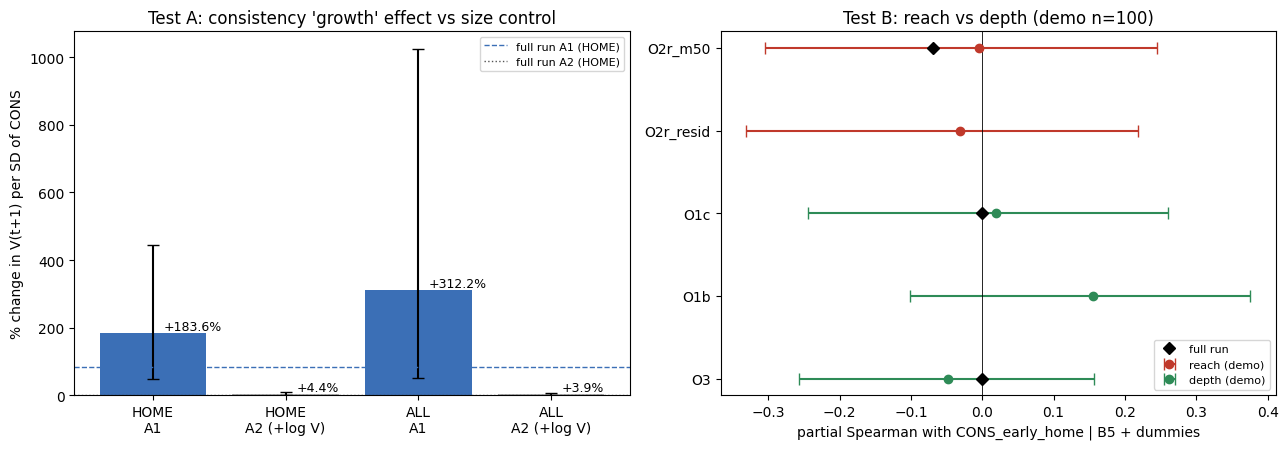

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Test A: A1 vs A2 per build
ax = axes[0]
labs, vals, los, his = [], [], [], []
for build in ["HOME", "ALL"]:
    for m in ["A1", "A2"]:
        c = res_A["builds"][build]["joint"][m]["coef"]["zCONS"]
        labs.append(f"{build}\n{m}{' (+log V)' if m == 'A2' else ''}")
        vals.append(100 * c["pct_per_sd"])
        los.append(100 * c["pct_per_sd"] - 100 * c["pct_ci"][0])
        his.append(100 * c["pct_ci"][1] - 100 * c["pct_per_sd"])
cols = ["#3b6fb6", "#b0b0b0", "#3b6fb6", "#b0b0b0"]
ax.bar(range(len(vals)), vals, yerr=[los, his], color=cols, capsize=4)
for k, v in enumerate(vals):
    ax.text(k + 0.08, v, f"{v:+.1f}%", ha="left", va="bottom", fontsize=9)
ax.axhline(100 * ref[H + "A1.coef.zCONS.pct_per_sd"], color="#3b6fb6", ls="--", lw=1, label="full run A1 (HOME)")
ax.axhline(100 * ref[H + "A2.coef.zCONS.pct_per_sd"], color="#555", ls=":", lw=1, label="full run A2 (HOME)")
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labs)
ax.set_ylabel("% change in V(t+1) per SD of CONS")
ax.set_title("Test A: consistency 'growth' effect vs size control")
ax.legend(fontsize=8)

# --- Test B: psp forest, reach vs depth
ax = axes[1]
ys = ["O2r_m50", "O2r_resid", "O1c", "O1b", "O3"]
full_keys = {"O2r_m50": S + "psp.O2r_m50.rho", "O1c": S + "psp.O1c.rho", "O3": S + "psp.O3.rho"}
for k, y in enumerate(ys):
    r = p_prim["psp"][y]
    col = "#c0392b" if y.startswith("O2r") else "#2e8b57"
    if r["rho"] is not None:
        ax.errorbar(r["rho"], k, xerr=[[r["rho"] - r["ci"][0]], [r["ci"][1] - r["rho"]]], fmt="o", color=col,
                    capsize=4, label=("reach (demo)" if y == "O2r_m50" else "depth (demo)" if y == "O1c" else None))
    if y in full_keys:
        ax.plot(ref[full_keys[y]], k, "D", color="k", ms=6, label="full run" if y == "O2r_m50" else None)
ax.axvline(0, color="k", lw=0.6)
ax.set_yticks(range(len(ys)))
ax.set_yticklabels(ys)
ax.invert_yaxis()
ax.set_xlabel("partial Spearman with CONS_early_home | B5 + dummies")
ax.set_title(f"Test B: reach vs depth (demo n={p_prim['psp']['O2r_m50']['n']})")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()